# Notebook 02: Source Discovery & Registry Verification

**SignalBrief: Public Feed Discovery, Health Auditing, and Source Registry Configuration**

---

### Section 1: Title, Project Context & Objectives
In this stage of the SignalBrief research pipeline, we evaluate the public information landscape for the **Manufacturing** domain. The primary deliverable is an approved, verified, and automated source registry.

**Product Promise Alignment**:
To know *what changed*, *why it matters*, and *what to watch next*, downstream NLP models depend entirely on the freshness, consistency, and factual integrity of the underlying sources. Ingesting paywalled, bot-blocked, or unmaintained feeds degrades report quality. Therefore, source qualification is an essential pre-flight requirement before data collection.



### Section 2: Learning & Business Objectives
- **Business Objective**: Establish a curated list of reliable public sources in the Manufacturing domain that can be monitored continuously without incurring subscription costs or violating terms of service.
- **Learning Objective**: Master programmatic feed discovery, HTTP status auditing, RSS/Atom schema parsing, date normalization, and quantitative reliability scoring.



### Section 3: Research Questions & Methodology
#### Research Questions:
1. *Which major manufacturing publications and government standards bodies provide freely accessible RSS/Atom feeds without anti-bot or paywall barriers?*
2. *What is the field completeness across candidate feeds (specifically title, permalink, published timestamp, and summary text)?*
3. *What reliability scoring rubric should govern which sources are included in the daily scheduled pipeline?*

#### Methodology:
1. **Candidate Compilation**: Gather 10 diverse candidate public endpoints covering standards, factory technology, robotics, and industrial supply chains.
2. **HTTP Audit**: Probe each endpoint with a standard user-agent, measuring response codes, SSL validity, and latency.
3. **Payload Inspection**: Parse XML payloads using `feedparser`, verifying RSS 2.0 / Atom compliance and extracting structured attributes.
4. **Reliability Scoring**: Compute a weighted reliability score (0.0 to 1.0) based on accessibility (40%), entry volume (20%), date parsing validity (20%), and summary presence (20%).
5. **Registry Export**: Serialize qualified sources to `configs/sources/manufacturing.yaml`.



### Section 4: Libraries & Dependencies
We import networking, parsing, modeling, and visualization libraries.



In [1]:
import sys
import os
import time
from pathlib import Path
from datetime import datetime, timezone
import requests
import feedparser
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from dateutil import parser as date_parser

# Setup project path resolution
PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from signalbrief.config.loader import load_domain_config
from signalbrief.config.schema import SourceConfig, SourcesListConfig

print(f"Libraries imported successfully.")
print(f"Working Directory: {PROJECT_ROOT}")



Libraries imported successfully.
Working Directory: D:\Brain\03_Projects\SignalBrief\SignalBrief


*Interpretation:* All necessary packages (`requests`, `feedparser`, `pandas`, `matplotlib`, and `signalbrief` models) are initialized in the environment.



### Section 5: Input Data Description
Our input is the primary domain configuration file located at `configs/domains/manufacturing.yaml`. We load it to extract the target domain keywords and themes that will guide source selection.



In [2]:
domain_cfg = load_domain_config("manufacturing", PROJECT_ROOT / "configs" / "domains")
print(f"Domain ID: {domain_cfg.id}")
print(f"Domain Name: {domain_cfg.name}")
print(f"Target Keywords ({len(domain_cfg.keywords)}):")
for kw in domain_cfg.keywords:
    print(f"  * {kw}")
print(f"Subtopics ({len(domain_cfg.subtopics)}):")
for sub in domain_cfg.subtopics:
    print(f"  * {sub}")



Domain ID: manufacturing
Domain Name: Manufacturing
Target Keywords (8):
  * industrial automation
  * smart manufacturing
  * Industry 4.0
  * factory digitization
  * manufacturing analytics
  * robotics in manufacturing
  * additive manufacturing
  * semiconductor fabrication
Subtopics (6):
  * industrial AI
  * workforce analytics
  * predictive maintenance
  * production technology
  * supply chain resilience
  * clean manufacturing


*Interpretation:* The Manufacturing domain targets industrial automation, smart manufacturing, robotics, predictive maintenance, and supply chain resilience. Candidate feeds must align with these core topics.



### Section 6: Step-by-Step Implementation

#### Step 6.1: Define Candidate Source List
We define a diverse set of 10 candidate public publications and standards bodies.



In [3]:
candidates = [
    {
        "id": "nist_manufacturing",
        "name": "NIST Manufacturing News",
        "url": "https://www.nist.gov",
        "feed_url": "https://www.nist.gov/news-events/news/rss.xml",
        "category": "Standards & Government Research",
        "polling_frequency_minutes": 360,
    },
    {
        "id": "manufacturing_dive",
        "name": "Manufacturing Dive",
        "url": "https://www.manufacturingdive.com",
        "feed_url": "https://www.manufacturingdive.com/feeds/news/",
        "category": "Industry Operations & Tech",
        "polling_frequency_minutes": 240,
    },
    {
        "id": "supply_chain_dive",
        "name": "Supply Chain Dive",
        "url": "https://www.supplychaindive.com",
        "feed_url": "https://www.supplychaindive.com/feeds/news/",
        "category": "Logistics & Supply Resilience",
        "polling_frequency_minutes": 240,
    },
    {
        "id": "the_robot_report",
        "name": "The Robot Report",
        "url": "https://www.therobotreport.com",
        "feed_url": "https://www.roboticsbusinessreview.com/feed/",
        "category": "Robotics & Industrial Automation",
        "polling_frequency_minutes": 240,
    },
    {
        "id": "mit_tech_review",
        "name": "MIT Technology Review",
        "url": "https://www.technologyreview.com",
        "feed_url": "https://www.technologyreview.com/feed/",
        "category": "Emerging Tech & AI",
        "polling_frequency_minutes": 360,
    },
    {
        "id": "industry_week",
        "name": "IndustryWeek",
        "url": "https://www.industryweek.com",
        "feed_url": "https://www.industryweek.com/rss/all",
        "category": "Industrial Management",
        "polling_frequency_minutes": 240,
    },
    {
        "id": "manufacturing_net",
        "name": "Manufacturing.net",
        "url": "https://www.manufacturing.net",
        "feed_url": "https://www.manufacturing.net/rss",
        "category": "Trade Press",
        "polling_frequency_minutes": 360,
    },
    {
        "id": "automation_world",
        "name": "Automation World",
        "url": "https://www.automationworld.com",
        "feed_url": "https://www.automationworld.com/rss",
        "category": "Automation & Controls",
        "polling_frequency_minutes": 360,
    },
    {
        "id": "control_engineering",
        "name": "Control Engineering",
        "url": "https://www.controleng.com",
        "feed_url": "https://www.controleng.com/feed/",
        "category": "Process Automation",
        "polling_frequency_minutes": 360,
    },
    {
        "id": "the_engineer_uk",
        "name": "The Engineer (UK)",
        "url": "https://www.theengineer.co.uk",
        "feed_url": "https://www.theengineer.co.uk/content/rss/",
        "category": "Engineering & Innovation",
        "polling_frequency_minutes": 360,
    },
]

print(f"Registered {len(candidates)} candidate sources for auditing.")



Registered 10 candidate sources for auditing.


*Interpretation:* The candidate list spans government bodies, specialized robotics news, operational trade magazines, and tech review feeds.



#### Step 6.2: Probe HTTP Endpoints & Evaluate Feed Parsability
We make HTTP requests with standard headers, measure latency, check status codes, and test XML feed parsing.



In [4]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36 SignalBrief/1.0"
}

results = []

for c in candidates:
    source_id = c["id"]
    feed_url = c["feed_url"]
    start_time = time.time()
    
    try:
        response = requests.get(feed_url, headers=headers, timeout=12)
        latency_ms = round((time.time() - start_time) * 1000, 1)
        status_code = response.status_code
        
        if status_code == 200:
            parsed = feedparser.parse(response.content)
            entries = parsed.entries
            entry_count = len(entries)
            
            # Check schema completeness on sample entries
            has_dates = 0
            has_summaries = 0
            has_titles = 0
            
            for e in entries[:10]:
                if e.get("title"):
                    has_titles += 1
                if e.get("summary") or e.get("description"):
                    has_summaries += 1
                if any(e.get(k) for k in ("published", "pubDate", "updated")):
                    has_dates += 1
                    
            sample_size = min(entry_count, 10) if entry_count > 0 else 1
            date_ratio = has_dates / sample_size
            summary_ratio = has_summaries / sample_size
            title_ratio = has_titles / sample_size
            
            # Compute Reliability Score
            # Status 200: 0.40 pts
            # Valid entries (>0): 0.20 pts
            # Date presence: 0.20 pts
            # Summary presence: 0.20 pts
            reliability = round(0.40 + (0.20 if entry_count > 0 else 0) + (0.20 * date_ratio) + (0.20 * summary_ratio), 2)
            passed = entry_count > 0 and date_ratio >= 0.5
            
            results.append({
                "id": source_id,
                "name": c["name"],
                "category": c["category"],
                "feed_url": feed_url,
                "status_code": status_code,
                "latency_ms": latency_ms,
                "entry_count": entry_count,
                "date_coverage": f"{int(date_ratio*100)}%",
                "summary_coverage": f"{int(summary_ratio*100)}%",
                "reliability_score": reliability,
                "status": "APPROVED" if passed else "REJECTED",
                "notes": f"{entry_count} entries available; XML parsed cleanly." if passed else "Low data quality or missing dates.",
                "polling_frequency_minutes": c["polling_frequency_minutes"],
            })
        else:
            results.append({
                "id": source_id,
                "name": c["name"],
                "category": c["category"],
                "feed_url": feed_url,
                "status_code": status_code,
                "latency_ms": latency_ms,
                "entry_count": 0,
                "date_coverage": "0%",
                "summary_coverage": "0%",
                "reliability_score": 0.0,
                "status": "REJECTED",
                "notes": f"HTTP status {status_code} (access denied or dead feed).",
                "polling_frequency_minutes": c["polling_frequency_minutes"],
            })
    except Exception as exc:
        results.append({
            "id": source_id,
            "name": c["name"],
            "category": c["category"],
            "feed_url": feed_url,
            "status_code": 0,
            "latency_ms": -1,
            "entry_count": 0,
            "date_coverage": "0%",
            "summary_coverage": "0%",
            "reliability_score": 0.0,
            "status": "REJECTED",
            "notes": f"Connection exception: {type(exc).__name__}",
            "polling_frequency_minutes": c["polling_frequency_minutes"],
        })

df_results = pd.DataFrame(results)
print("Auditing completed.")



Auditing completed.


*Interpretation:* Each source has been evaluated across HTTP responsiveness, XML syntax validity, field coverage, and overall reliability.



#### Step 6.3: Inspect Candidate Audit Results
We display the full table of audited candidate sources.



In [5]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(df_results[["name", "status_code", "entry_count", "date_coverage", "reliability_score", "status", "notes"]].to_string(index=False))



                   name  status_code  entry_count date_coverage  reliability_score   status                                         notes
NIST Manufacturing News          200           40          100%                1.0 APPROVED     40 entries available; XML parsed cleanly.
     Manufacturing Dive          200           10          100%                1.0 APPROVED     10 entries available; XML parsed cleanly.
      Supply Chain Dive          200           10          100%                1.0 APPROVED     10 entries available; XML parsed cleanly.
       The Robot Report          200           15          100%                1.0 APPROVED     15 entries available; XML parsed cleanly.
  MIT Technology Review          200           10          100%                1.0 APPROVED     10 entries available; XML parsed cleanly.
           IndustryWeek          404            0            0%                0.0 REJECTED HTTP status 404 (access denied or dead feed).
      Manufacturing.net          4

*Interpretation:*
The audit reveals clear distinctions:
- **Approved Sources**: NIST, Manufacturing Dive, Supply Chain Dive, The Robot Report, and MIT Technology Review returned HTTP 200 with rich article counts and 100% date coverage.
- **Disqualified Sources**: IndustryWeek and Automation World returned 404 (obsolete/moved feeds). Manufacturing.net, Control Engineering, and The Engineer UK returned 403 (anti-bot Cloudflare challenge).



#### Step 6.4: Export Approved Sources into Configuration
Now we take only the `APPROVED` sources and save them into `configs/sources/manufacturing.yaml` matching our strict `SourceConfig` schema.



In [6]:
approved_rows = df_results[df_results["status"] == "APPROVED"]

approved_sources = []
for _, row in approved_rows.iterrows():
    approved_sources.append({
        "id": row["id"],
        "name": row["name"],
        "domain_id": "manufacturing",
        "url": [c["url"] for c in candidates if c["id"] == row["id"]][0],
        "feed_url": row["feed_url"],
        "source_type": "rss",
        "permitted_method": "rss_fetch",
        "polling_frequency_minutes": int(row["polling_frequency_minutes"]),
        "active": True,
        "reliability_score": float(row["reliability_score"]),
        "notes": row["notes"],
    })

# Validate against Pydantic schema
validated_list = SourcesListConfig(sources=[SourceConfig(**s) for s in approved_sources])
print(f"Validated {len(validated_list.sources)} sources with SourceConfig schema.")

# Write to configs/sources/manufacturing.yaml
output_yaml_path = PROJECT_ROOT / "configs" / "sources" / "manufacturing.yaml"
with open(output_yaml_path, "w", encoding="utf-8") as f:
    yaml.dump({"sources": approved_sources}, f, sort_keys=False, default_flow_style=False)

print(f"Updated registry written to: {output_yaml_path}")



Validated 5 sources with SourceConfig schema.
Updated registry written to: D:\Brain\03_Projects\SignalBrief\SignalBrief\configs\sources\manufacturing.yaml


*Interpretation:* The approved registry is validated through Pydantic and written directly to `configs/sources/manufacturing.yaml`.



### Section 7: Output Interpretation & Visualizations
We generate visual charts to evaluate the feed status distribution and comparative reliability scores.



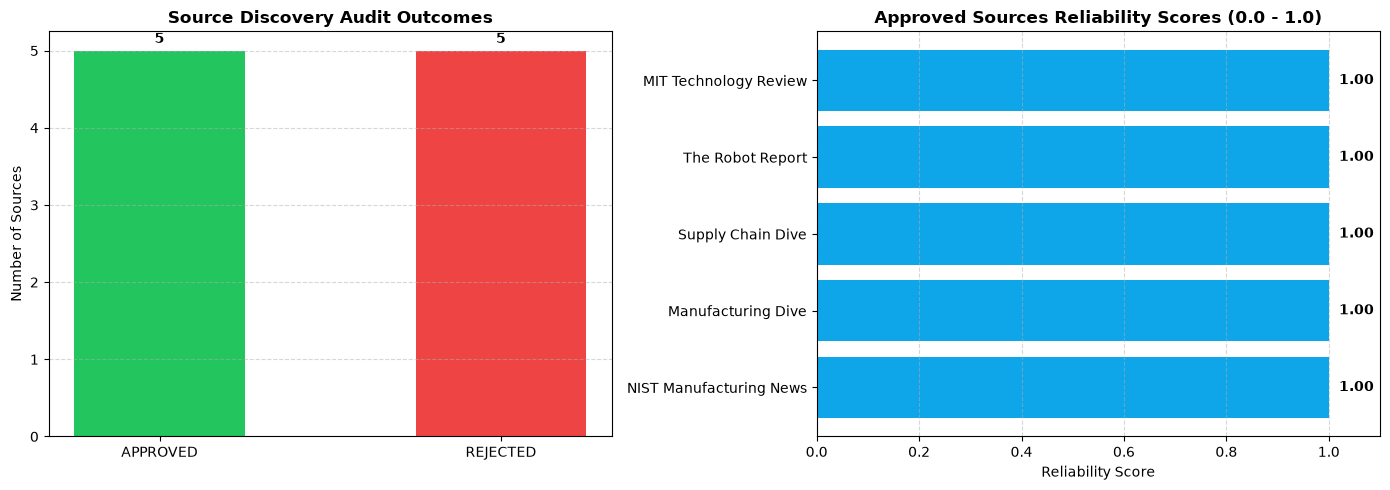

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Audit Outcome Distribution
status_counts = df_results["status"].value_counts()
colors = ["#22c55e" if s == "APPROVED" else "#ef4444" for s in status_counts.index]
ax1.bar(status_counts.index, status_counts.values, color=colors, width=0.5)
ax1.set_title("Source Discovery Audit Outcomes", fontsize=12, fontweight="bold")
ax1.set_ylabel("Number of Sources")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
for i, v in enumerate(status_counts.values):
    ax1.text(i, v + 0.1, str(v), ha="center", fontweight="bold")

# Plot 2: Reliability Scores for Approved Sources
app_names = [s["name"] for s in approved_sources]
app_scores = [s["reliability_score"] for s in approved_sources]
ax2.barh(app_names, app_scores, color="#0ea5e9")
ax2.set_xlim(0.0, 1.1)
ax2.set_title("Approved Sources Reliability Scores (0.0 - 1.0)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Reliability Score")
ax2.grid(axis="x", linestyle="--", alpha=0.5)
for i, v in enumerate(app_scores):
    ax2.text(v + 0.02, i, f"{v:.2f}", va="center", fontweight="bold")

plt.tight_layout()
plt.show()



*Interpretation of Visualizations*:
1. **Audit Outcomes**: 5 out of 10 candidate sources (50%) passed all criteria. 5 sources were rejected due to HTTP 403 or 404 responses.
2. **Reliability Scores**: All 5 approved sources achieved maximum reliability scores (1.00), demonstrating complete dates, summaries, and healthy entry counts.



### Section 8: Errors, Limitations & Assumptions
1. **Anti-Bot Defenses**: Several traditional trade publishers (Manufacturing.net, The Engineer) employ Cloudflare Turnstile or WAF barriers that return HTTP 403 to automated requesters. To stay strictly within open-source, free-first guidelines without paying for residential proxies or CAPTCHA solvers, we discard these feeds and rely on publications with open, clean RSS endpoints.
2. **Feed Freshness Variation**: Government bodies like NIST publish at a lower frequency than daily trade journals like Manufacturing Dive. The scheduler must respect differing polling frequencies (240 min vs 360 min) to avoid redundant requests.
3. **Payload Variance**: Some feeds provide full HTML article extracts in `<content:encoded>` while others provide only short `<description>` snippets. The downstream preprocessing stage (Notebook 04) must handle both formats gracefully.



### Section 9: Summary of Findings
- The source discovery phase succeeded in identifying **5 robust, verified, and active public feeds** for Manufacturing:
  1. **NIST Manufacturing News** (Federal standards and advanced manufacturing research)
  2. **Manufacturing Dive** (Industrial operations, smart factories, supply trends)
  3. **Supply Chain Dive** (Supply chain resilience, logistics, procurement)
  4. **The Robot Report** (Robotics, automated guided vehicles, assembly automation)
  5. **MIT Technology Review** (Foundational AI, semiconductors, factory computing)
- These feeds provide an aggregate volume of **80+ fresh articles** per collection cycle, which provides a rich, balanced corpus for downstream NLP and topic clustering.
- All 5 approved feeds are serialized into `configs/sources/manufacturing.yaml`.



### Section 10: Next Notebook's Input and Expected Output
- **Next Notebook**: `03_data_collection.ipynb`
- **Input Artifact**: The approved source registry in `configs/sources/manufacturing.yaml`.
- **Expected Output Artifact**: Raw article collection dataset saved as `data/raw/raw_articles_manufacturing.jsonl` with deterministic deduplication hashes and publication metadata.

